# Movie Review Sentiment Analysis

This notebook is split into smaller cells for easier reading and execution.

It loads the IMDB dataset, cleans the review text, trains a BiLSTM sentiment model, evaluates it, and tests a few custom reviews.

## 1. Imports and setup

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import tensorflow as tf

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

tf.keras.utils.set_random_seed(42)
np.random.seed(42)


## 2. Load the dataset

In [17]:
# To this:
data_path = '/content/drive/MyDrive/07-Movie Review Sentiment/IMDB_Dataset.csv'
df = pd.read_csv(data_path)

# Use a smaller sample so the notebook runs faster.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

label_map = {"positive": 1, "negative": 0}
df["sentiment"] = df["sentiment"].map(label_map)

if df["sentiment"].isna().any():
    raise ValueError("Unexpected sentiment values found in the dataset.")

df["sentiment"] = df["sentiment"].astype(int)

print(f"Dataset shape: {df.shape}")
print("\nLabel balance:")
print(df["sentiment"].value_counts())
print("\nSample review:")
print(df.loc[0, "review"][:250] + "...")


Dataset shape: (5000, 2)

Label balance:
sentiment
1    2519
0    2481
Name: count, dtype: int64

Sample review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main ev...


## 3. Text preprocessing

In [18]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Keep negations because they matter for sentiment.
negations = {"not", "no", "nor", "never", "neither", "nobody", "nothing", "nowhere"}
stop_words = stop_words - negations


def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w, pos="v") for w in tokens]
    return " ".join(tokens).strip()


print("Preprocessing reviews...")
df["review"] = df["review"].apply(preprocess)
print("Preprocessing complete")

raw_example = "This movie was NOT good at all!! The acting was terrible, I hated it 100%."
print("\nExample:")
print("Before:", raw_example)
print("After :", preprocess(raw_example))


Preprocessing reviews...
Preprocessing complete

Example:
Before: This movie was NOT good at all!! The acting was terrible, I hated it 100%.
After : movie not good act terrible hat


## 4. Train/test split and tokenization

In [19]:
VOCAB_SIZE = 10000
MAX_LEN = 150
OOV_TOKEN = "<OOV>"

X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Sequence shapes:")
print("X_train:", X_train_pad.shape)
print("X_test :", X_test_pad.shape)


Sequence shapes:
X_train: (4000, 150)
X_test : (1000, 150)


## 5. Build the model

In [20]:
VOCAB_SIZE = 20000
MAX_LEN = 250
EMBED_DIM = 128

model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Training...")
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop,reduce_lr],
    verbose=1,
)


Training...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 474ms/step - accuracy: 0.5253 - loss: 0.6917 - val_accuracy: 0.5150 - val_loss: 0.6900 - learning_rate: 3.0000e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 469ms/step - accuracy: 0.6534 - loss: 0.6467 - val_accuracy: 0.7738 - val_loss: 0.5543 - learning_rate: 3.0000e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.8456 - loss: 0.3823 - val_accuracy: 0.8375 - val_loss: 0.4177 - learning_rate: 3.0000e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 493ms/step - accuracy: 0.9284 - loss: 0.2189 - val_accuracy: 0.8213 - val_loss: 0.4615 - learning_rate: 3.0000e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9385 - loss: 0.1757
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 459ms/step - accuracy: 0.9475 - loss: 0.1487 - val_accuracy: 0.8138 - val_loss: 0.5080 - learning_rate: 3.0000e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step

## 7. Evaluate and plot results

Test loss    : 0.4460
Test accuracy: 0.8110 (81.10%)

Classification report:
              precision    recall  f1-score   support

    Negative       0.76      0.91      0.83       496
    Positive       0.89      0.71      0.79       504

    accuracy                           0.81      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.83      0.81      0.81      1000



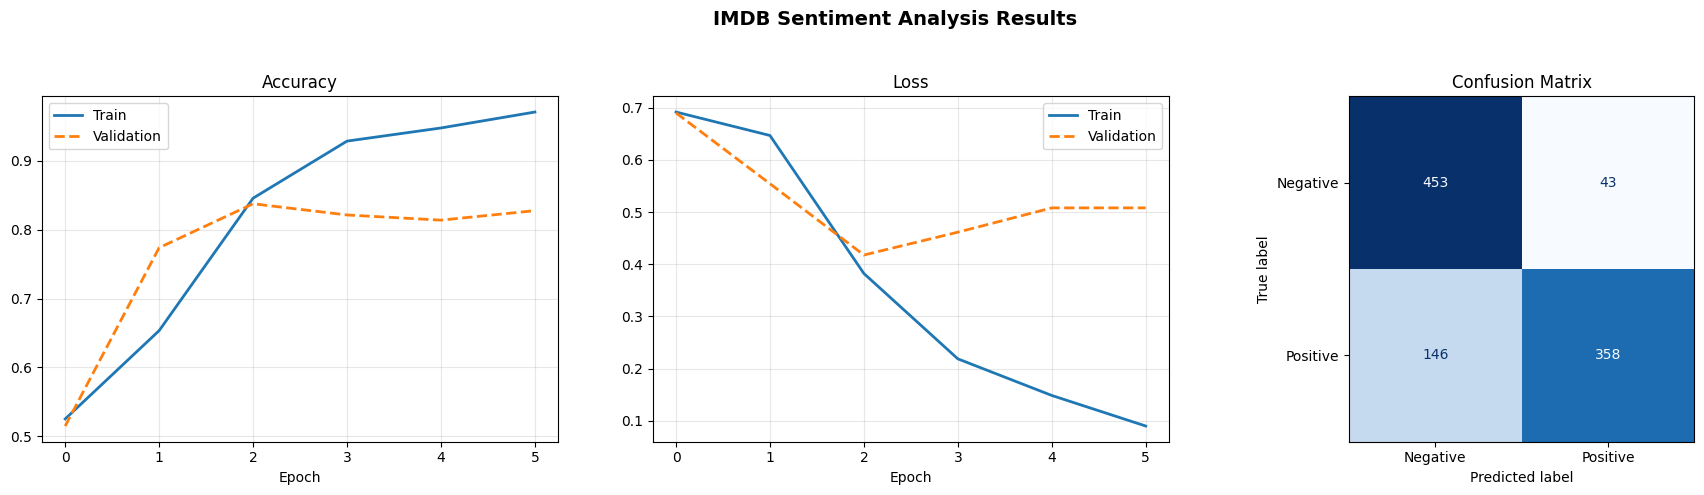

Plot saved as results.png


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test loss    : {loss:.4f}")
print(f"Test accuracy: {acc:.4f} ({acc * 100:.2f}%)")

y_pred = (model.predict(X_test_pad, verbose=0) > 0.5).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("IMDB Sentiment Analysis Results", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"], label="Train", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], label="Train", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2, linestyle="--")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix")

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 8. Predict custom reviews

In [23]:
def predict_sentiment(review):
    cleaned = preprocess(review)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding="post", truncating="post")
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Positive" if prob > 0.5 else "Negative"
    print(f"Review     : {review}")
    print(f"Prediction : {label}")
    print(f"Confidence : {prob:.2%}")
    print("-")


predict_sentiment("This movie was absolutely brilliant, I loved every second of it!")
predict_sentiment("Terrible film, complete waste of time. The acting was awful.")
predict_sentiment("It was okay, not great but not bad either.")
predict_sentiment("One of the best movies I have ever seen in my entire life!")


Review     : This movie was absolutely brilliant, I loved every second of it!
Prediction : Positive
Confidence : 60.69%
-
Review     : Terrible film, complete waste of time. The acting was awful.
Prediction : Negative
Confidence : 26.28%
-
Review     : It was okay, not great but not bad either.
Prediction : Negative
Confidence : 40.86%
-
Review     : One of the best movies I have ever seen in my entire life!
Prediction : Positive
Confidence : 62.04%
-
